# LSTM Model Training for WESAD Dataset

This notebook trains an LSTM model to classify stress, amusement, and baseline states using the WESAD dataset.

In [1]:
import os
import pickle
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import glob

## 1. Configuration and Setup

In [2]:
# Configuration
DATASET_PATH = '../../Dataset/WESAD'
TARGET_USERS = ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']
TARGET_LABELS = {1: 0, 2: 1, 3: 2} # 1: baseline, 2: stress, 3: amusement -> 0, 1, 2
N_FEATURES = 6 # ACC (3), BVP (1), EDA (1), TEMP (1)
DOWNSAMPLE_RATE = 4 # Hz, the rate to downsample all signals to
WINDOW_SIZE_SEC = 60 # seconds
STRIDE_SEC = 1 # seconds

# LSTM Hyperparameters
HIDDEN_DIM = 128
LAYER_DIM = 2
OUTPUT_DIM = len(TARGET_LABELS)
BATCH_SIZE = 64
NUM_EPOCHS = 20
LEARNING_RATE = 0.001

# Setup device
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda:0


## 2. Data Loading and Preprocessing

In [3]:
def load_and_preprocess_data(subject_path):
    """Loads a single subject's data, downsamples, and synchronizes."""
    with open(subject_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')

    # --- Extract Wrist Data --- #
    wrist_data = data['signal']['wrist']
    acc = wrist_data['ACC']
    bvp = wrist_data['BVP']
    eda = wrist_data['EDA']
    temp = wrist_data['TEMP']
    labels = data['label']

    # --- Downsample --- #
    # Original sampling rates: ACC=32Hz, BVP=64Hz, EDA=4Hz, TEMP=4Hz, label=700Hz
    acc_down = acc[::32 // DOWNSAMPLE_RATE]
    bvp_down = bvp[::64 // DOWNSAMPLE_RATE]
    eda_down = eda[::4 // DOWNSAMPLE_RATE]
    temp_down = temp[::4 // DOWNSAMPLE_RATE]
    
    # Align labels by resampling at the data points' timestamps
    label_timestamps = np.arange(0, len(labels) / 700.0, 1/700.0)
    data_timestamps = np.arange(0, len(acc_down) / DOWNSAMPLE_RATE, 1/DOWNSAMPLE_RATE)
    idx = np.searchsorted(label_timestamps, data_timestamps, side='left')
    idx = np.clip(idx, 0, len(labels) - 1)
    labels_down = labels[idx].astype(int)
    
    # Find the minimum length to truncate all signals
    min_len = min(len(acc_down), len(bvp_down), len(eda_down), len(temp_down), len(labels_down))
    
    # --- Combine Features --- #
    # Shape: (min_len, N_FEATURES)
    features = np.concatenate([
        acc_down[:min_len],
        bvp_down[:min_len],
        eda_down[:min_len],
        temp_down[:min_len]
    ], axis=1)
    
    labels_final = labels_down[:min_len]
    
    return features, labels_final

def create_windows(features, labels):
    """Creates sliding windows of data and corresponding labels."""
    window_samples = WINDOW_SIZE_SEC * DOWNSAMPLE_RATE
    stride_samples = STRIDE_SEC * DOWNSAMPLE_RATE

    X, y = [], []
    for i in range(0, len(features) - window_samples, stride_samples):
        window_features = features[i : i + window_samples]
        window_labels = labels[i : i + window_samples]
        
        # Use the most frequent label in the window as the segment's label
        most_frequent_label = np.bincount(window_labels).argmax()
        
        if most_frequent_label in TARGET_LABELS:
            X.append(window_features)
            y.append(TARGET_LABELS[most_frequent_label])

    return np.array(X), np.array(y)


In [4]:
# --- Process all subjects --- #
all_X, all_y = [], []
for user in TARGET_USERS:
    subject_path = os.path.join(DATASET_PATH, user, f'{user}.pkl')
    if os.path.exists(subject_path):
        print(f'Processing {user}...')
        features, labels = load_and_preprocess_data(subject_path)
        X, y = create_windows(features, labels)
        all_X.append(X)
        all_y.append(y)

X_combined = np.concatenate(all_X, axis=0)
y_combined = np.concatenate(all_y, axis=0)

print(f'\nTotal windows created: {len(X_combined)}')
print(f'Feature shape: {X_combined.shape}')
print(f'Label distribution: {np.bincount(y_combined)}')

# --- Split Data FIRST (Data Leakage 방지) --- #
# Train/Val/Test = 70% / 15% / 15%
X_train_unshaped, X_temp_unshaped, y_train, y_temp = train_test_split(
    X_combined, y_combined, test_size=0.3, random_state=42, stratify=y_combined
)

# Val/Test = 50% / 50% (of temp 30%)
X_val_unshaped, X_test_unshaped, y_val, y_test = train_test_split(
    X_temp_unshaped, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f'\nTrain set size: {len(X_train_unshaped)}')
print(f'Val set size: {len(X_val_unshaped)}')
print(f'Test set size: {len(X_test_unshaped)}')

# --- Normalize Features (훈련 데이터로만 fit) --- #
# Reshape for scaler: (num_samples * window_length, num_features)
scaler = StandardScaler()

# 훈련 데이터를 reshape하여 fit
X_train_reshaped = X_train_unshaped.reshape(-1, N_FEATURES)
scaler.fit(X_train_reshaped)  # ✓ 훈련 데이터로만 fit

# 훈련, 검증, 테스트 데이터 모두에 transform 적용
X_train_scaled_reshaped = scaler.transform(X_train_reshaped)
X_val_reshaped = X_val_unshaped.reshape(-1, N_FEATURES)
X_val_scaled_reshaped = scaler.transform(X_val_reshaped)
X_test_reshaped = X_test_unshaped.reshape(-1, N_FEATURES)
X_test_scaled_reshaped = scaler.transform(X_test_reshaped)

# 원래 shape로 복원
X_train = X_train_scaled_reshaped.reshape(X_train_unshaped.shape)
X_val = X_val_scaled_reshaped.reshape(X_val_unshaped.shape)
X_test = X_test_scaled_reshaped.reshape(X_test_unshaped.shape)

Processing S2...
Processing S3...
Processing S4...
Processing S5...
Processing S6...
Processing S7...
Processing S8...
Processing S9...
Processing S10...
Processing S11...
Processing S13...
Processing S14...
Processing S15...
Processing S16...
Processing S17...

Total windows created: 33140
Feature shape: (33140, 240, 6)
Label distribution: [17605  9963  5572]

Train set size: 23198
Val set size: 4971
Test set size: 4971


## 3. PyTorch Dataset and DataLoader

In [5]:
class WesadDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = WesadDataset(X_train, y_train)
val_dataset = WesadDataset(X_val, y_val)
test_dataset = WesadDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## 4. LSTM Model Definition

In [6]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        
        # Use nn.LSTM which is more standard and efficient
        self.lstm = nn.LSTM(input_dim, hidden_dim, layer_dim, batch_first=True, dropout=0.3)
        
        # Fully connected layer
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        # Initialize hidden and cell states
        h0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).to(device).requires_grad_()
        c0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).to(device).requires_grad_()
        
        # We need to detach as we are doing truncated backpropagation through time (BPTT)
        # If we don't, we'll backprop all the way to the start of the sequence
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        
        # Index hidden state of last time step
        out = self.fc(out[:, -1, :]) 
        return out


## 5. Model Training

In [7]:
model = LSTMModel(N_FEATURES, HIDDEN_DIM, LAYER_DIM, OUTPUT_DIM)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("Starting training...")

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for i, (sequences, labels) in enumerate(train_loader):
        sequences = sequences.to(device)
        labels = labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(sequences)
        loss = criterion(outputs, labels)
        
        # Backward and optimize
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * sequences.size(0)
        
        # Calculate accuracy
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / total_samples
    epoch_acc = (correct_predictions / total_samples) * 100
    
    print(f'Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%')

Starting training...
Epoch [1/20], Loss: 0.7007, Accuracy: 70.58%
Epoch [2/20], Loss: 0.6789, Accuracy: 70.70%
Epoch [3/20], Loss: 0.6385, Accuracy: 72.98%
Epoch [4/20], Loss: 0.5473, Accuracy: 77.14%
Epoch [5/20], Loss: 0.5607, Accuracy: 77.19%
Epoch [6/20], Loss: 0.5379, Accuracy: 77.88%
Epoch [7/20], Loss: 0.5174, Accuracy: 78.96%
Epoch [8/20], Loss: 0.4445, Accuracy: 82.45%
Epoch [9/20], Loss: 0.4743, Accuracy: 80.43%
Epoch [10/20], Loss: 0.4195, Accuracy: 83.80%
Epoch [11/20], Loss: 0.3008, Accuracy: 88.48%
Epoch [12/20], Loss: 0.6069, Accuracy: 75.04%
Epoch [13/20], Loss: 0.5300, Accuracy: 77.83%
Epoch [14/20], Loss: 0.4165, Accuracy: 83.88%
Epoch [15/20], Loss: 0.3373, Accuracy: 87.15%
Epoch [16/20], Loss: 0.2410, Accuracy: 91.30%
Epoch [17/20], Loss: 0.2412, Accuracy: 91.09%
Epoch [18/20], Loss: 0.1931, Accuracy: 92.79%
Epoch [19/20], Loss: 0.2344, Accuracy: 91.96%
Epoch [20/20], Loss: 0.2476, Accuracy: 90.96%


## 6. Model Evaluation

In [8]:
model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for sequences, labels in test_loader:
        sequences = sequences.to(device)
        labels = labels.to(device)
        
        outputs = model(sequences)
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = 100 * correct / total
print(f'\nTest Accuracy: {accuracy:.2f} %')

# Optional: Print classification report for more details
try:
    from sklearn.metrics import classification_report
    report = classification_report(all_labels, all_preds, target_names=['baseline', 'stress', 'amusement'])
    print("\nClassification Report:")
    print(report)
except ImportError:
    print("\nPlease install scikit-learn to see the classification report: pip install -U scikit-learn")

# 각 클래스별 정확도 계산
all_labels_np = np.array(all_labels)
all_preds_np = np.array(all_preds)

class_names = ['Baseline', 'Stress', 'Amusement']
print("\n" + "="*60)
print("각 상태별 정확도")
print("="*60)

for class_idx, class_name in enumerate(class_names):
    # 해당 클래스의 샘플들
    class_mask = all_labels_np == class_idx
    class_total = class_mask.sum()
    
    if class_total > 0:
        # 해당 클래스에서 올바르게 예측된 샘플들
        class_correct = ((all_labels_np == class_idx) & (all_preds_np == class_idx)).sum()
        class_accuracy = (class_correct / class_total) * 100
        print(f"{class_name}: {class_accuracy:.2f}% ({class_correct}/{class_total})")
    else:
        print(f"{class_name}: N/A (no samples)")

print("="*60)


Test Accuracy: 91.47 %

Classification Report:
              precision    recall  f1-score   support

    baseline       0.90      0.96      0.93      2641
      stress       0.94      0.89      0.91      1494
   amusement       0.91      0.82      0.87       836

    accuracy                           0.91      4971
   macro avg       0.92      0.89      0.90      4971
weighted avg       0.92      0.91      0.91      4971


각 상태별 정확도
Baseline: 95.95% (2534/2641)
Stress: 88.62% (1324/1494)
Amusement: 82.42% (689/836)


## 7. Data Analysis: Characteristics of Each State

각 상태(Baseline, Stress, Amusement)의 센서 데이터 특징을 분석합니다.

In [9]:
# 한 명의 피험자 데이터를 로드하여 각 상태별 특징 분석
sample_subject = 'S2'
subject_path = os.path.join(DATASET_PATH, sample_subject, f'{sample_subject}.pkl')

with open(subject_path, 'rb') as f:
    data = pickle.load(f, encoding='latin1')

# Extract signals
wrist = data['signal']['wrist']
acc = wrist['ACC']  # Accelerometer (3축)
bvp = wrist['BVP']  # Blood Volume Pulse
eda = wrist['EDA']  # Electrodermal Activity (피부전기활동)
temp = wrist['TEMP']  # Skin Temperature
labels = data['label']

# Downsample to 4Hz
acc_down = acc[::32 // 4]
bvp_down = bvp[::64 // 4]
eda_down = eda[::4 // 4]
temp_down = temp[::4 // 4]
labels_down = labels[::700 // 4]

# Align lengths
min_len = min(len(acc_down), len(bvp_down), len(eda_down), len(temp_down), len(labels_down))
acc_down = acc_down[:min_len]
bvp_down = bvp_down[:min_len]
eda_down = eda_down[:min_len]
temp_down = temp_down[:min_len]
labels_down = labels_down[:min_len].astype(int)

print(f"데이터 길이: {min_len} samples (at 4Hz)")
print(f"레이블 분포: {np.bincount(labels_down)}")
print(f"고유 레이블: {np.unique(labels_down)}")

데이터 길이: 24316 samples (at 4Hz)
레이블 분포: [12244  4576  2460  1448  3072     0   260   256]
고유 레이블: [0 1 2 3 4 6 7]


In [15]:
# 각 상태별 통계 분석
import pandas as pd

states = {1: 'Baseline', 2: 'Stress', 3: 'Amusement'}
stats_list = []

for label_num, label_name in states.items():
    mask = labels_down == label_num
    if mask.sum() > 0:
        # ACC magnitude (3축의 크기)
        acc_mag = np.sqrt(np.sum(acc_down[mask]**2, axis=1))
        
        stats = {
            'State': label_name,
            'Samples': mask.sum(),
            'ACC_X_mean': acc_down[mask][:, 0].mean(),
            'ACC_X_std': acc_down[mask][:, 0].std(),
            'ACC_Y_mean': acc_down[mask][:, 1].mean(),
            'ACC_Y_std': acc_down[mask][:, 1].std(),
            'ACC_Z_mean': acc_down[mask][:, 2].mean(),
            'ACC_Z_std': acc_down[mask][:, 2].std(),
            'ACC_magnitude_mean': acc_mag.mean(),
            'ACC_magnitude_std': acc_mag.std(),
            'BVP_mean': bvp_down[mask].mean(),
            'BVP_std': bvp_down[mask].std(),
            'EDA_mean': eda_down[mask].mean(),
            'EDA_std': eda_down[mask].std(),
            'TEMP_mean': temp_down[mask].mean(),
            'TEMP_std': temp_down[mask].std(),
        }
        stats_list.append(stats)

df_stats = pd.DataFrame(stats_list)
print(f"\n=== {sample_subject} 피험자의 각 상태별 센서 데이터 통계 ===\n")
print(df_stats.to_string(index=False))


=== S2 피험자의 각 상태별 센서 데이터 통계 ===

    State  Samples  ACC_X_mean  ACC_X_std  ACC_Y_mean  ACC_Y_std  ACC_Z_mean  ACC_Z_std  ACC_magnitude_mean  ACC_magnitude_std  BVP_mean   BVP_std  EDA_mean  EDA_std  TEMP_mean  TEMP_std
 Baseline     4576   48.946897  12.729897   18.508960  10.970315    6.521635  31.077995           63.403876           3.016676 -0.358011 64.911004  0.297881 0.309248  35.786198  0.108444
   Stress     2460   17.187805   6.017496  -58.593902   3.004016   13.711789   3.959277           63.010803           2.688511 -0.635020 76.083655  0.870277 0.204461  33.442098  0.462643
Amusement     1448   51.100138  16.322088   16.600829  25.646897   -7.921271  11.424960           63.258529           1.618727 -0.199344 48.090798  0.206203 0.038276  34.190884  0.120213


In [16]:
# 주요 특징 비교 (상대적 변화율)
print("\n=== 주요 센서 특징 비교 (Baseline 대비) ===\n")
baseline_idx = df_stats[df_stats['State'] == 'Baseline'].index[0]

for metric in ['BVP_mean', 'EDA_mean', 'TEMP_mean', 'ACC_magnitude_mean']:
    print(f"\n{metric}:")
    baseline_val = df_stats.loc[baseline_idx, metric]
    for idx, row in df_stats.iterrows():
        if row['State'] != 'Baseline':
            change = ((row[metric] - baseline_val) / baseline_val) * 100
            print(f"  {row['State']}: {row[metric]:.4f} (Baseline 대비 {change:+.2f}%)")
        else:
            print(f"  {row['State']}: {row[metric]:.4f} (기준)")


=== 주요 센서 특징 비교 (Baseline 대비) ===


BVP_mean:
  Baseline: -0.3580 (기준)
  Stress: -0.6350 (Baseline 대비 +77.37%)
  Amusement: -0.1993 (Baseline 대비 -44.32%)

EDA_mean:
  Baseline: 0.2979 (기준)
  Stress: 0.8703 (Baseline 대비 +192.16%)
  Amusement: 0.2062 (Baseline 대비 -30.78%)

TEMP_mean:
  Baseline: 35.7862 (기준)
  Stress: 33.4421 (Baseline 대비 -6.55%)
  Amusement: 34.1909 (Baseline 대비 -4.46%)

ACC_magnitude_mean:
  Baseline: 63.4039 (기준)
  Stress: 63.0108 (Baseline 대비 -0.62%)
  Amusement: 63.2585 (Baseline 대비 -0.23%)


C:\Users\mbnv6\AppData\Local\Temp\ipykernel_11000\602739894.py:28: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_11000\602739894.py:28: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_11000\602739894.py:28: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_11000\602739894.py:28: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_11000\602739894.py:28: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_11000\602739894.py:28: UserWarning: Glyph 53468 (\N{HANGUL SYLLABLE TAE}) missing from font(

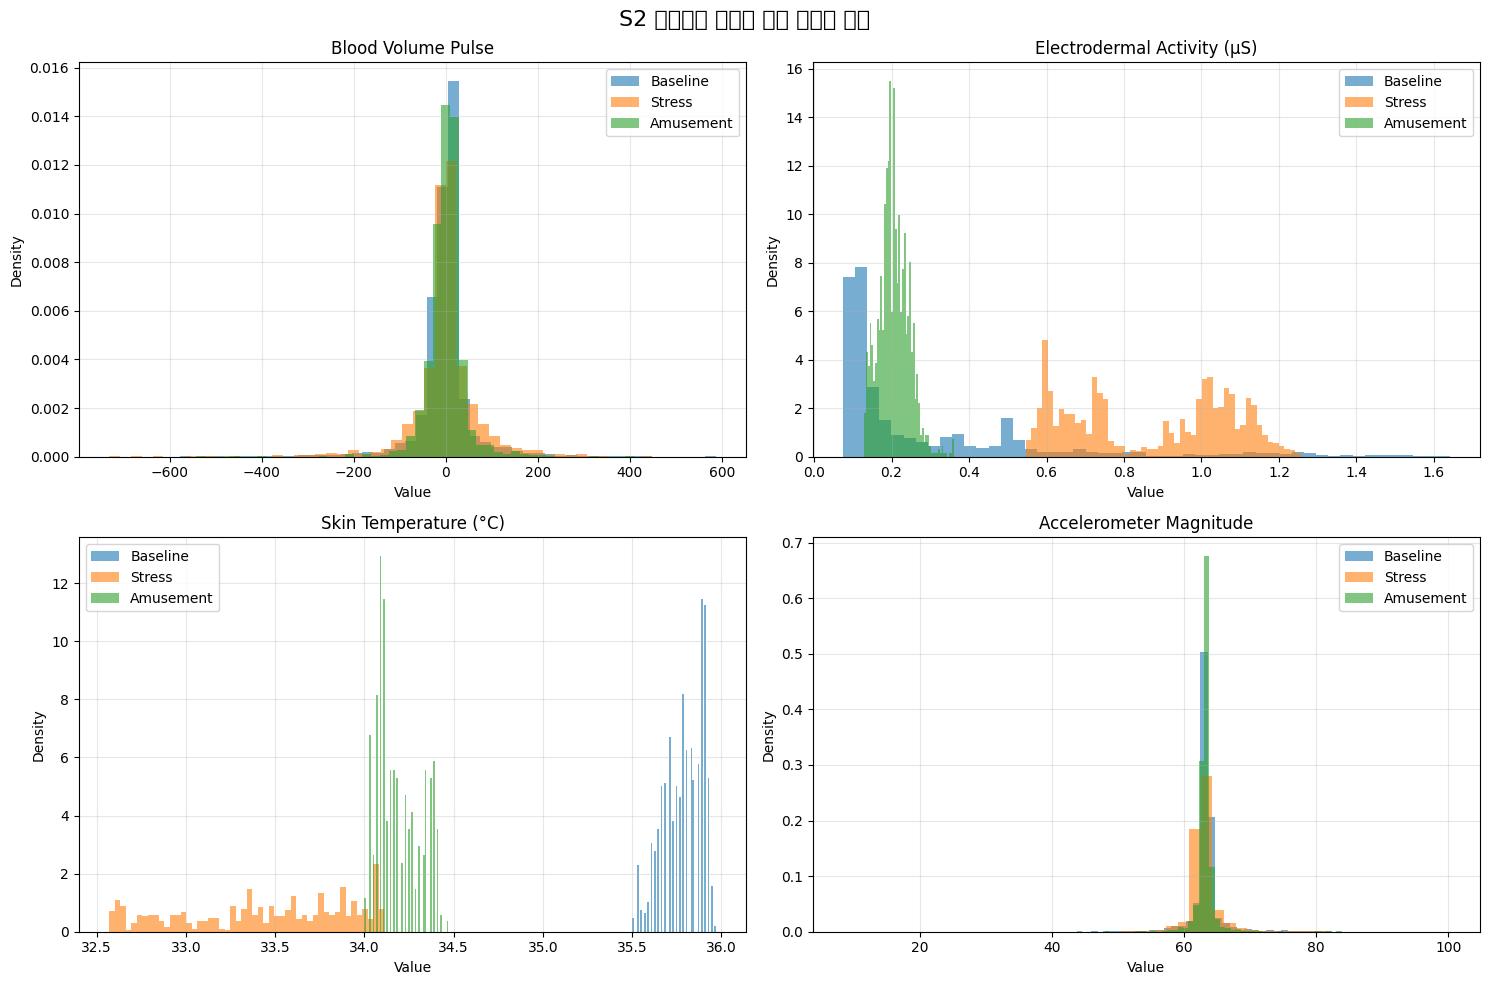

In [17]:
# 시각화: 각 상태별 센서 데이터 분포
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f'{sample_subject} 피험자의 상태별 센서 데이터 분포', fontsize=16)

sensors = [
    ('BVP', bvp_down, 'Blood Volume Pulse'),
    ('EDA', eda_down, 'Electrodermal Activity (μS)'),
    ('TEMP', temp_down, 'Skin Temperature (°C)'),
    ('ACC_mag', np.sqrt(np.sum(acc_down**2, axis=1)), 'Accelerometer Magnitude')
]

for idx, (sensor_name, sensor_data, title) in enumerate(sensors):
    ax = axes[idx // 2, idx % 2]
    
    for label_num, label_name in states.items():
        mask = labels_down == label_num
        if mask.sum() > 0:
            ax.hist(sensor_data[mask], bins=50, alpha=0.6, label=label_name, density=True)
    
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\mbnv6\AppData\Local\Temp\ipykernel_11000\2191540109.py:39: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_11000\2191540109.py:39: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_11000\2191540109.py:39: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_11000\2191540109.py:39: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_11000\2191540109.py:39: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mbnv6\AppData\Local\Temp\ipykernel_11000\2191540109.py:39: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from

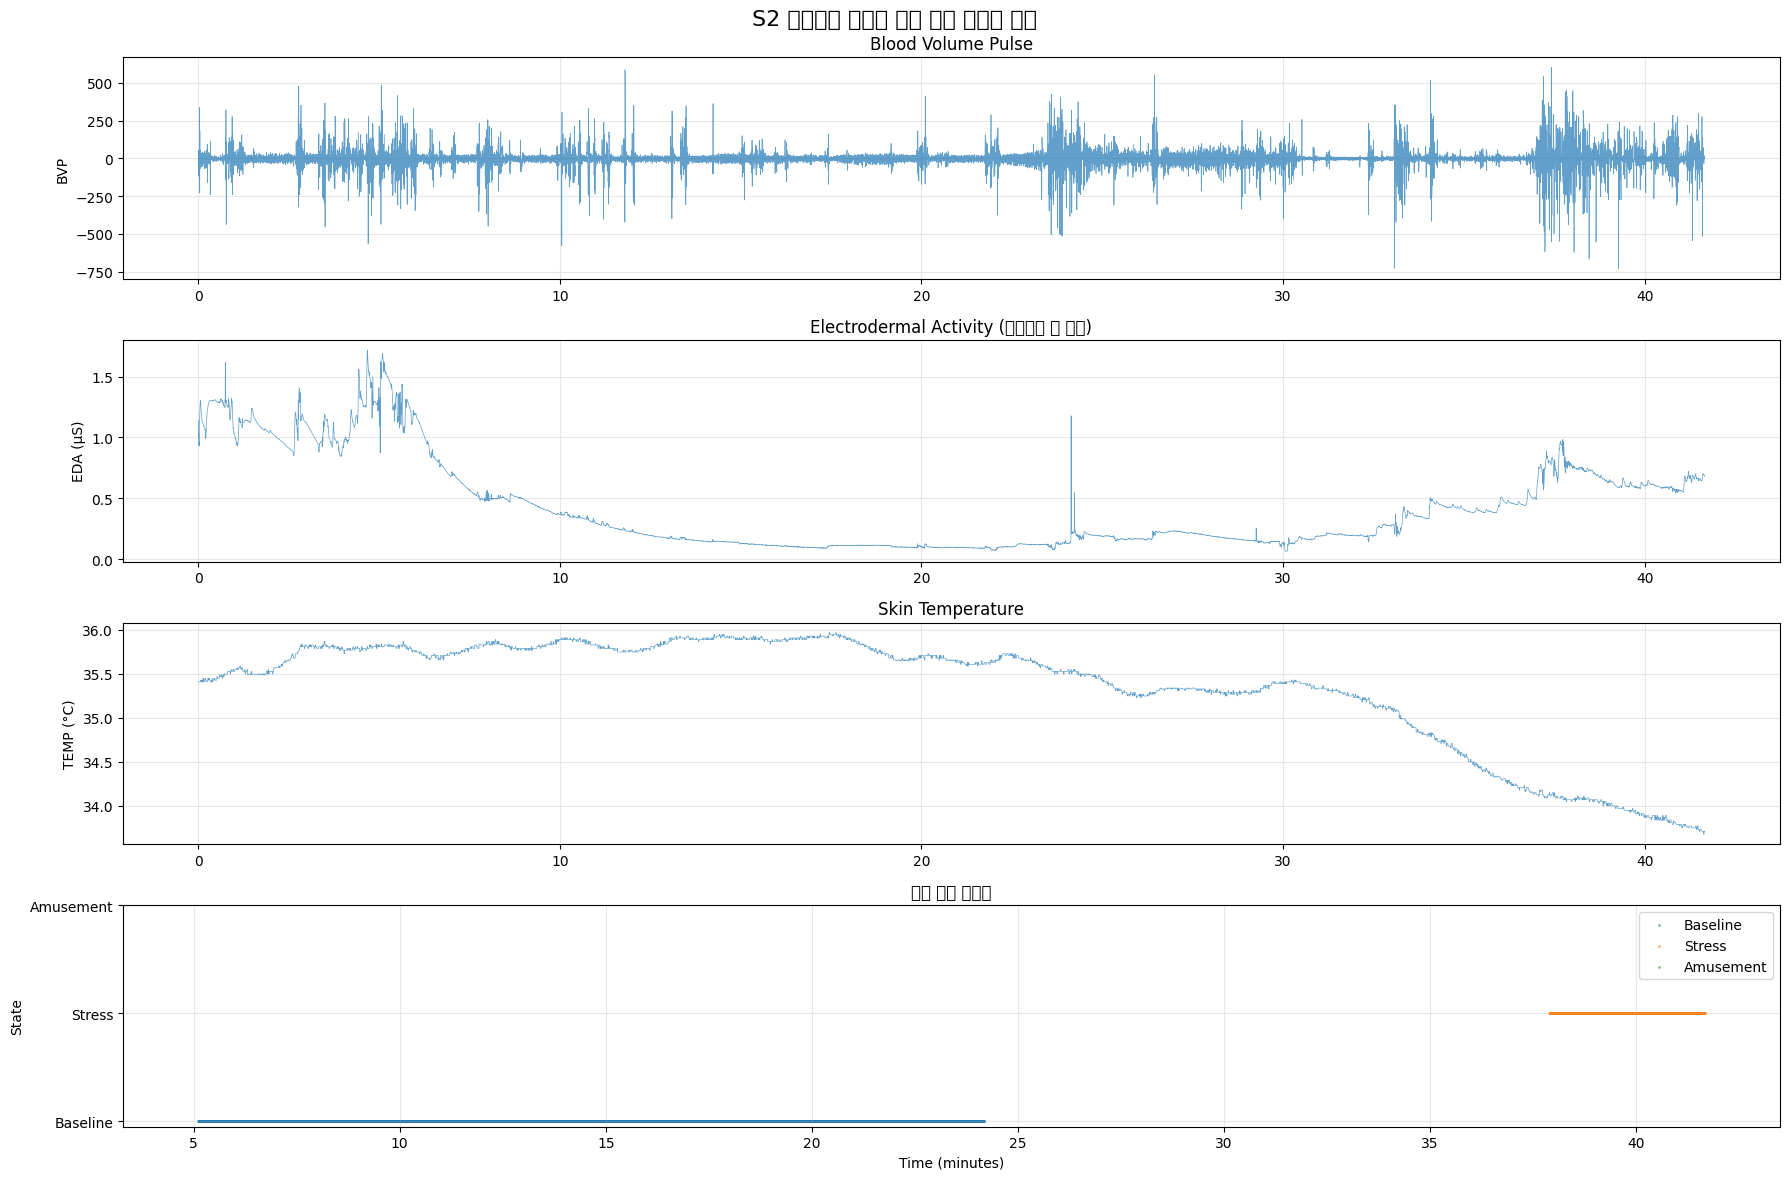

In [18]:
# 시계열 시각화: 각 상태의 센서 데이터 변화 패턴
fig, axes = plt.subplots(4, 1, figsize=(18, 12))
fig.suptitle(f'{sample_subject} 피험자의 시간에 따른 센서 데이터 변화', fontsize=16)

# 전체 데이터의 일부만 시각화 (처음 10000 samples, 약 40분)
plot_len = min(10000, len(labels_down))
time_axis = np.arange(plot_len) / DOWNSAMPLE_RATE / 60  # minutes

# BVP
axes[0].plot(time_axis, bvp_down[:plot_len, 0], linewidth=0.5, alpha=0.7)
axes[0].set_ylabel('BVP')
axes[0].set_title('Blood Volume Pulse')
axes[0].grid(True, alpha=0.3)

# EDA
axes[1].plot(time_axis, eda_down[:plot_len, 0], linewidth=0.5, alpha=0.7)
axes[1].set_ylabel('EDA (μS)')
axes[1].set_title('Electrodermal Activity (스트레스 시 증가)')
axes[1].grid(True, alpha=0.3)

# TEMP
axes[2].plot(time_axis, temp_down[:plot_len, 0], linewidth=0.5, alpha=0.7)
axes[2].set_ylabel('TEMP (°C)')
axes[2].set_title('Skin Temperature')
axes[2].grid(True, alpha=0.3)

# Labels (상태)
for label_num, label_name in states.items():
    mask = labels_down[:plot_len] == label_num
    axes[3].scatter(time_axis[mask], [label_num]*mask.sum(), s=1, alpha=0.5, label=label_name)
axes[3].set_ylabel('State')
axes[3].set_xlabel('Time (minutes)')
axes[3].set_title('실험 상태 레이블')
axes[3].set_yticks([1, 2, 3])
axes[3].set_yticklabels(['Baseline', 'Stress', 'Amusement'])
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 각 상태의 생리학적 특징 해석

**🔵 Baseline (기준선)**
- 평상시 안정된 상태
- 모든 센서 값이 안정적이고 변동이 적음
- 참고 기준값

**🔴 Stress (스트레스)**
- **EDA (피부전기활동) ↑**: 스트레스를 받으면 땀샘 활동 증가로 피부 전도도 상승
- **심박수/BVP ↑**: 교감신경 활성화로 심박수 증가
- **피부온도**: 상황에 따라 변동 (긴장 시 손발이 차가워질 수 있음)
- **ACC**: 움직임 패턴 변화 (긴장으로 인한 미세한 움직임)

**🟢 Amusement (즐거움)**
- **BVP**: 리듬이 더 안정적이고 규칙적
- **EDA**: Baseline보다 높을 수 있으나 Stress보다는 낮음
- **피부온도**: 비교적 안정적
- **ACC**: 웃거나 즐거워할 때의 움직임 패턴